In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

tickers = ["PETR4.SA", "VALE3.SA", "ITUB4.SA"]
pesos = [1/3, 1/3, 1/3]

precos = yf.download(tickers, start="2020-01-01", end="2024-12-31")["Close"]

log_ret = np.log(precos / precos.shift(1)).dropna()

ret_portfolio = (log_ret * pesos).sum(axis=1)

media = ret_portfolio.mean()
desvio = ret_portfolio.std()

z_scores = (ret_portfolio - media) / desvio

print(f"Media  : {media:.6f}")
print(f"Desvio : {desvio:.6f}")
print(f"Media normalizada  : {z_scores.mean():.6f}")
print(f"Desvio normalizado : {z_scores.std():.6f}")

/tmp/ipykernel_13463/2620882986.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(tickers, start="2020-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  3 of 3 completed

Media  : 0.000481
Desvio : 0.019354
Media normalizada  : 0.000000
Desvio normalizado : 1.000000


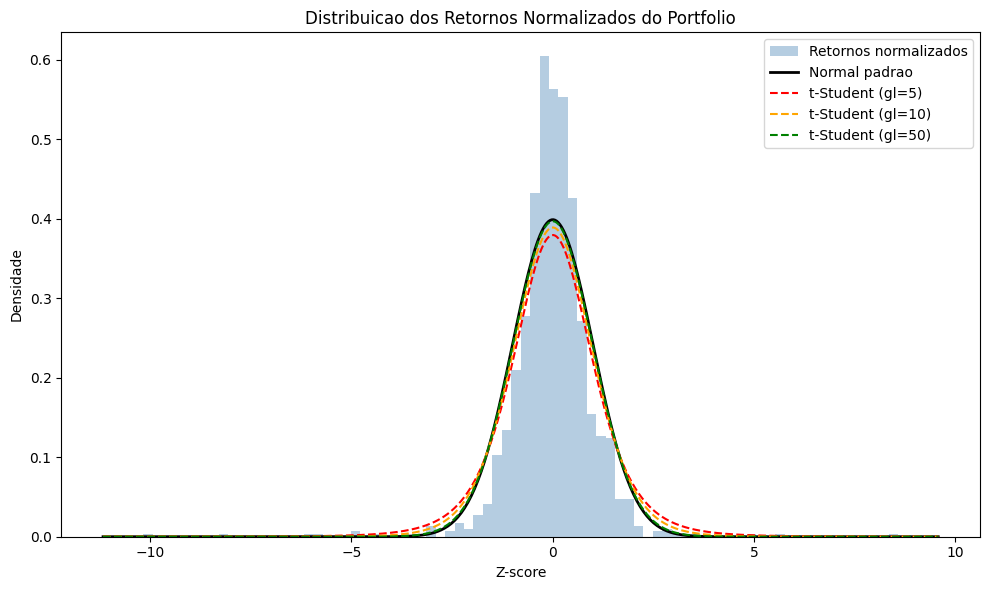

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(z_scores.min() - 1, z_scores.max() + 1, 500)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(z_scores, bins=80, density=True, alpha=0.4, color="steelblue", label="Retornos normalizados")
ax.plot(x, stats.norm.pdf(x, 0, 1), color="black", linewidth=2, label="Normal padrao")

cores = ["red", "orange", "green"]
for gl, cor in zip([5, 10, 50], cores):
    ax.plot(x, stats.t.pdf(x, df=gl), color=cor, linewidth=1.5, linestyle="--", label=f"t-Student (gl={gl})")

ax.set_title("Distribuicao dos Retornos Normalizados do Portfolio")
ax.set_xlabel("Z-score")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
from scipy import stats

prob = 1 - stats.norm.cdf(0.03, loc=media, scale=desvio)

print(f"Media diaria  : {media:.6f}")
print(f"Desvio padrao : {desvio:.6f}")
print(f"P(retorno > 3%) = {prob:.4f} = {prob*100:.2f}%")

Media diaria  : 0.000481
Desvio padrao : 0.019354
P(retorno > 3%) = 0.0636 = 6.36%


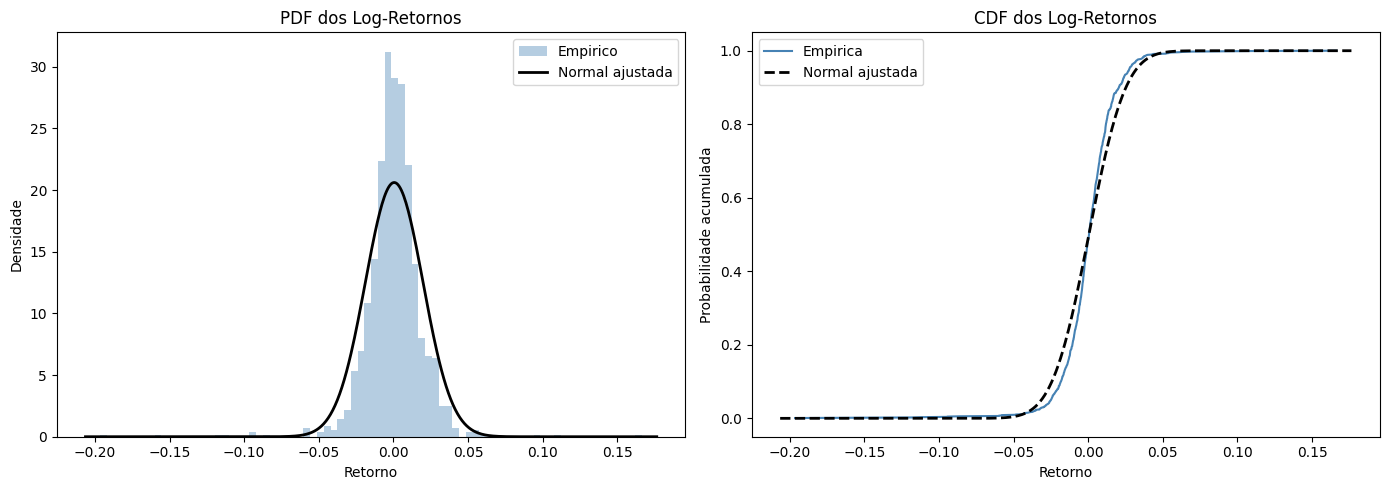

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(ret_portfolio.min() - 0.01, ret_portfolio.max() + 0.01, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(ret_portfolio, bins=80, density=True, alpha=0.4, color="steelblue", label="Empirico")
ax1.plot(x, stats.norm.pdf(x, media, desvio), color="black", linewidth=2, label="Normal ajustada")
ax1.set_title("PDF dos Log-Retornos")
ax1.set_xlabel("Retorno")
ax1.set_ylabel("Densidade")
ax1.legend()

retornos_ordenados = np.sort(ret_portfolio)
cdf_empirica = np.arange(1, len(retornos_ordenados) + 1) / len(retornos_ordenados)

ax2.plot(retornos_ordenados, cdf_empirica, color="steelblue", linewidth=1.5, label="Empirica")
ax2.plot(x, stats.norm.cdf(x, media, desvio), color="black", linewidth=2, linestyle="--", label="Normal ajustada")
ax2.set_title("CDF dos Log-Retornos")
ax2.set_xlabel("Retorno")
ax2.set_ylabel("Probabilidade acumulada")
ax2.legend()

plt.tight_layout()
plt.show()

In [5]:
kurt = ret_portfolio.kurtosis()
skew = ret_portfolio.skew()

print(f"Skewness  : {skew:.4f}")
print(f"Kurtosis  : {kurt:.4f}")

Skewness  : -1.0575
Kurtosis  : 20.1610


In [6]:
from scipy import stats

p25 = stats.norm.ppf(0.25, loc=media, scale=desvio)
prob_negativo = stats.norm.cdf(0, loc=media, scale=desvio)

print(f"Percentil 25%          : {p25:.6f}  ({p25*100:.4f}%)")
print(f"% dias com retorno < 0 : {prob_negativo*100:.2f}%")

Percentil 25%          : -0.012573  (-1.2573%)
% dias com retorno < 0 : 49.01%


Maximo Drawdown: -52.90%
Data do fundo  : 2020-03-23


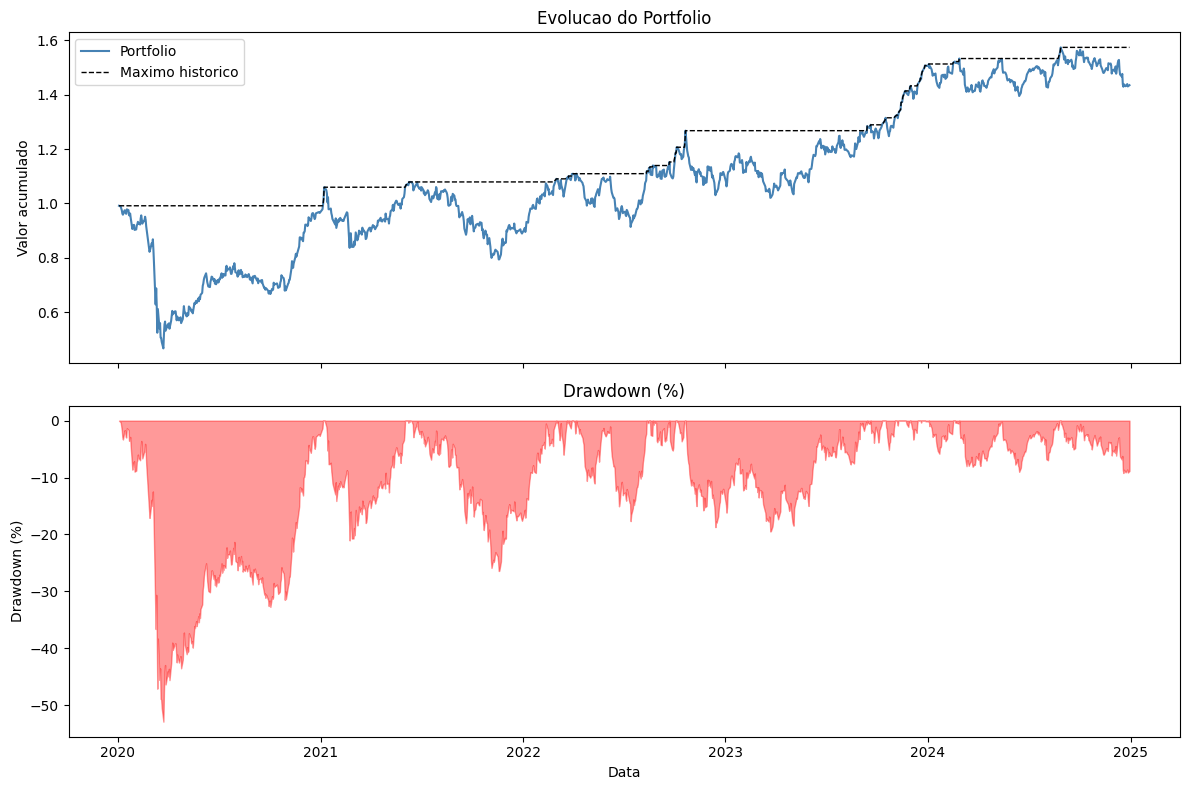

In [7]:
import numpy as np
import matplotlib.pyplot as plt

preco_acumulado = (1 + ret_portfolio).cumprod()
maximo_historico = preco_acumulado.cummax()
drawdown = (preco_acumulado - maximo_historico) / maximo_historico
max_drawdown = drawdown.min()

print(f"Maximo Drawdown: {max_drawdown*100:.2f}%")
print(f"Data do fundo  : {drawdown.idxmin().date()}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(preco_acumulado, color="steelblue", linewidth=1.5, label="Portfolio")
ax1.plot(maximo_historico, color="black", linewidth=1, linestyle="--", label="Maximo historico")
ax1.set_title("Evolucao do Portfolio")
ax1.set_ylabel("Valor acumulado")
ax1.legend()

ax2.fill_between(drawdown.index, drawdown * 100, 0, color="red", alpha=0.4)
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Data")

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats
import yfinance as yf
import numpy as np

t_stat, p_valor = stats.ttest_1samp(ret_portfolio, popmean=0)
print("Teste: media do portfolio = 0")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-valor     : {p_valor:.4f}")
rejeita = "Sim" if p_valor < 0.05 else "Nao"
print(f"  Rejeita H0 (alpha=5%)? {rejeita}")

ibov = yf.download("^BVSP", start="2020-01-01", end="2024-12-31")["Close"]
ret_ibov = np.log(ibov / ibov.shift(1)).dropna().squeeze()

ret_port_alinhado, ret_ibov_alinhado = ret_portfolio.align(ret_ibov, join="inner")

resultado = stats.ttest_ind(ret_port_alinhado, ret_ibov_alinhado)
t_stat2 = float(np.array(resultado.statistic).flat[0])
p_valor2 = float(np.array(resultado.pvalue).flat[0])

print("\nTeste: media do portfolio = media do IBOVESPA")
print(f"  t-statistic : {t_stat2:.4f}")
print(f"  p-valor     : {p_valor2:.4f}")
rejeita2 = "Sim" if p_valor2 < 0.05 else "Nao"
print(f"  Rejeita H0 (alpha=5%)? {rejeita2}")

/tmp/ipykernel_13463/174442922.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start="2020-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  1 of 1 completed

Teste: media do portfolio = 0
  t-statistic : 0.8760
  p-valor     : 0.3812
  Rejeita H0 (alpha=5%)? Nao

Teste: media do portfolio = media do IBOVESPA
  t-statistic : 0.6519
  p-valor     : 0.5145
  Rejeita H0 (alpha=5%)? Nao


In [9]:
!git config --global user.email "jbarros021105@gmail.com"
!git config --global user.name "Joao Marcel de Barros"

In [10]:
!git clone https://github.com/Treinamento-Quant/lista-02-joaombarros02.git

Cloning into 'lista-02-joaombarros02'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 21 (delta 5), reused 5 (delta 5), pack-reused 10 (from 1)
Receiving objects: 100% (21/21), 64.51 KiB | 6.45 MiB/s, done.
Resolving deltas: 100% (5/5), done.
